# Package 3 (v2) – Upsell Classification: Analysis & v1-vs-v2 Comparison

This notebook does **no additional model training**. It imports the already-fitted models, split, and result tables directly from `upsell_classification_v2.py` — importing it re-runs its cells once, which is how these become available here without retraining.

**Why v2 exists:** an audit of the whole project found that `upsell_classification.py` (v1) kept `ltv_months` as a feature, even though `ltv_months` is only fully known once a customer relationship has *ended* — the same category of late-relationship information Package 4 identified and removed in its own v1→v2 fix. `ltv_months` was v1's #1 feature at ~26% importance. `upsell_classification_v2.py` removes it (`LEAKAGE_COLS = ["cumulative_profit", "referred", "ltv_months"]`, vs. v1's `["cumulative_profit", "referred"]`) and is otherwise an exact structural mirror of v1, so the two are comparable apples-to-apples. The business-rule baseline was also updated: v1's rule used `ltv_months > median`, which is no longer available as a feature here, so v2 substitutes `purchased == 1` (a genuinely early-available signal in the same spirit) alongside the unchanged `customer_acquisition_cost` threshold.

Shape: (3490, 19)
Number of features: 15
Feature names: ['ad_budget', 'num_leads', 'leads_answered', 'leads_not_answered', 'followup_1', 'followup_2', 'followup_3', 'followup_4', 'followup_5', 'not_closed', 'closed', 'calls_to_closed', 'calls_to_not_closed', 'customer_acquisition_cost', 'purchased']
Class balance (y):
upsell
0    0.579943
1    0.420057
Name: proportion, dtype: float64
X_train shape: (2792, 15)
X_test shape:  (698, 15)
y_train shape: (2792,)
y_test shape:  (698,)
Train class balance:
upsell
0    0.579871
1    0.420129
Name: proportion, dtype: float64


Trained XGBoost
Trained LightGBM
Trained CatBoost


Best model by 5-fold CV F1: CatBoost
True negatives:  285
False positives: 120  (predicted upsell, but customer did not buy)
False negatives: 41  (customer would upsell, but model missed them)
True positives:  252


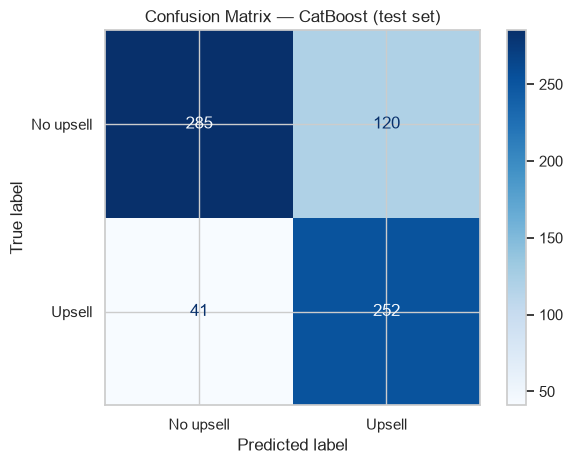

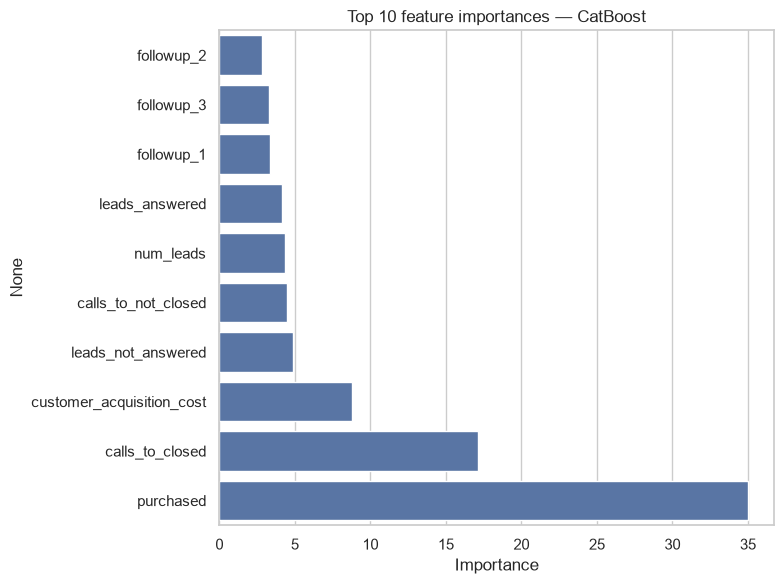

Top feature (purchased) share of total importance: 35.0%


In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from upsell_classification_v2 import (
    best_model_name,
    cm,
    cv_comparison,
    fn,
    fp,
    holdout_comparison,
    rule_vs_model,
    tn,
    top_10_features,
    tp,
)

sns.set_theme(style="whitegrid")

## Model Comparison — Cross-Validation Metrics

In [2]:
cv_comparison.style.background_gradient(
    subset=["Accuracy", "Precision", "Recall", "F1"], cmap="Greens"
).format(precision=3)

,Model,Accuracy,Precision,Recall,F1
0,CatBoost,0.781,0.695,0.854,0.766
1,LightGBM,0.763,0.679,0.825,0.745
2,XGBoost,0.743,0.667,0.775,0.717


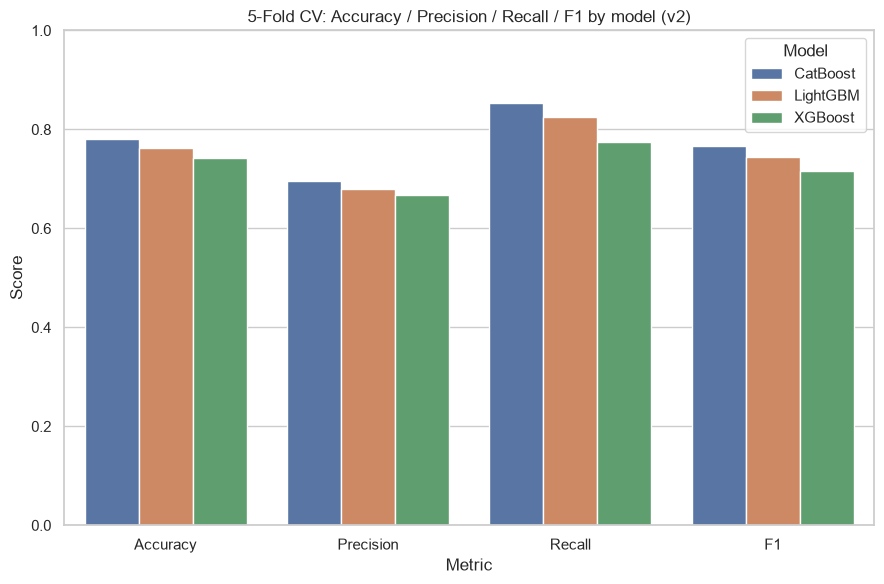

In [3]:
cv_long = cv_comparison.melt(id_vars="Model", var_name="Metric", value_name="Score")

plt.figure(figsize=(9, 6))
sns.barplot(data=cv_long, x="Metric", y="Score", hue="Model")
plt.ylim(0, 1)
plt.title("5-Fold CV: Accuracy / Precision / Recall / F1 by model (v2)")
plt.tight_layout()
plt.show()

CatBoost still leads on every CV metric except accuracy is close between all three, same ranking as v1. Its edge over LightGBM narrowed slightly compared to v1, but the ordering is unchanged.

## Final Model Selection & Test Performance

In [4]:
print(f"Selected model: {best_model_name}")
holdout_comparison.style.background_gradient(
    subset=["Accuracy", "Precision", "Recall", "F1"], cmap="Blues"
).format(precision=3)

Selected model: CatBoost


,Model,Accuracy,Precision,Recall,F1
0,CatBoost,0.769,0.677,0.860,0.758
1,LightGBM,0.762,0.676,0.833,0.746
2,XGBoost,0.742,0.667,0.771,0.715


## v1 vs. v2 — Was It Worth Losing ltv_months?

In [5]:
# v1 holdout metrics, reproduced from upsell_classification.py's actual verified
# run (not recomputed here — no retraining of v1 in this notebook).
v1_metrics = pd.DataFrame(
    [
        {
            "Version": "v1 (with ltv_months)",
            "Accuracy": 0.778,
            "Precision": 0.684,
            "Recall": 0.874,
            "F1": 0.768,
        }
    ]
)
v2_metrics = holdout_comparison[holdout_comparison["Model"] == best_model_name].copy()
v2_metrics.insert(0, "Version", "v2 (without ltv_months)")
v2_metrics = v2_metrics.drop(columns="Model")

version_comparison = pd.concat([v1_metrics, v2_metrics], ignore_index=True)
version_comparison.style.background_gradient(
    subset=["Accuracy", "Precision", "Recall", "F1"], cmap="Purples"
).format(precision=3)

,Version,Accuracy,Precision,Recall,F1
0,v1 (with ltv_months),0.778,0.684,0.874,0.768
1,v2 (without ltv_months),0.769,0.677,0.860,0.758


The drop is small: F1 falls from 0.768 (v1) to 0.758 (v2) — about one point, far smaller than the ~4-point drop seen in Package 4's own v1→v2 fix. The reason shows up in the feature-importance table below: `purchased`, which was already a legitimate feature in both versions, absorbs most of `ltv_months`'s predictive signal once `ltv_months` is removed (its importance roughly jumps from ~22% in v1 to ~35% in v2). CatBoost remains the best model in both versions — the fix didn't change which algorithm wins, only trimmed a small amount of performance that was resting on a genuinely unavailable-at-prediction-time feature.

## Confusion Matrix — Business Interpretation

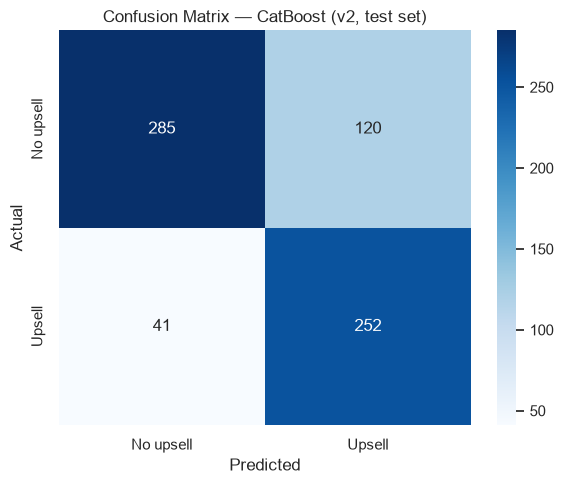

In [6]:
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No upsell", "Upsell"],
    yticklabels=["No upsell", "Upsell"],
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix — {best_model_name} (v2, test set)")
plt.tight_layout()
plt.show()

In [7]:
print(f"True negatives:  {tn}")
print(f"False positives: {fp}  (predicted upsell, customer did not buy — wasted outreach)")
print(f"False negatives: {fn}  (customer would upsell, model missed them — lost revenue)")
print(f"True positives:  {tp}")
print(f"False positive rate among predicted upsells: {fp / (fp + tp):.1%}")
print(f"False negative rate among actual upsells: {fn / (fn + tp):.1%}")

True negatives:  285
False positives: 120  (predicted upsell, customer did not buy — wasted outreach)
False negatives: 41  (customer would upsell, model missed them — lost revenue)
True positives:  252
False positive rate among predicted upsells: 32.3%
False negative rate among actual upsells: 14.0%


v2 misses slightly more real upsell customers than v1 did (41 vs. 37 false negatives) and flags slightly more false positives (120 vs. 118) — consistent with the small, expected performance cost of removing `ltv_months`. The overall pattern is unchanged: the model still favors **not missing opportunity** over avoiding wasted outreach.

## Feature Importance — Business Interpretation

In [8]:
top_10_features

purchased                    34.974140
calls_to_closed              17.127817
customer_acquisition_cost     8.750056
leads_not_answered            4.899970
calls_to_not_closed           4.450890
num_leads                     4.367315
leads_answered                4.168212
followup_1                    3.333613
followup_3                    3.262276
followup_2                    2.789870
dtype: float64

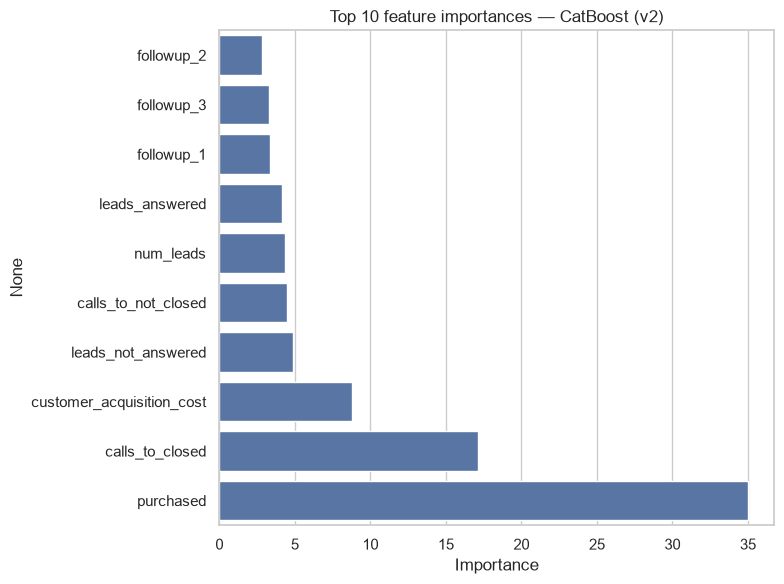

In [9]:
plt.figure(figsize=(8, 6))
plot_order = top_10_features.iloc[::-1]
sns.barplot(x=plot_order.to_numpy(), y=plot_order.index, orient="h")
plt.title(f"Top 10 feature importances — {best_model_name} (v2)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

**Is upsell driven by one dominant feature, or a combination?** More top-heavy than v1: `purchased` alone now carries ~35% of total importance (`top_share` above), with `calls_to_closed` a distant second (~17%). Together those two hold roughly half the model's decision weight, and the remaining eight features in the top 10 contribute modestly (`customer_acquisition_cost`, funnel-volume and follow-up columns).

**Is `purchased` itself a leakage risk?** Worth flagging honestly: `purchased` records whether a customer made their *initial* purchase — a near-immediate, early-relationship event (unlike `ltv_months`, which only resolves at the end). It is a legitimate, early-available signal for an upsell-scoring use case, not a repeat of the same problem this v2 was built to fix — but it is now doing more work than before, so it's worth confirming in any real deployment that `purchased` is indeed known before an upsell decision needs to be made.

## Business Rule Comparison

Baseline: flag a customer for outreach if they've already made an initial purchase (`purchased == 1`) and their acquisition cost is below the dataset median — replacing v1's `ltv_months`-based rule, which is no longer usable here for the same leakage reason as the model feature.

In [10]:
rule_vs_model

,Model,Accuracy,Precision,Recall,F1
0,CatBoost,0.769341,0.677419,0.860068,0.757895
1,Business rule,0.593123,0.525424,0.317406,0.395745


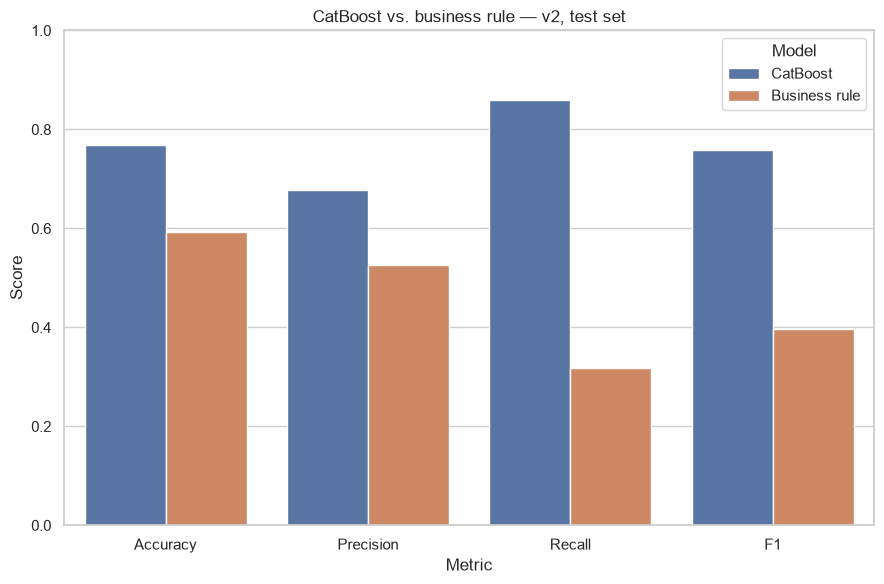

In [11]:
rule_long = rule_vs_model.melt(id_vars="Model", var_name="Metric", value_name="Score")

plt.figure(figsize=(9, 6))
sns.barplot(data=rule_long, x="Metric", y="Score", hue="Model")
plt.ylim(0, 1)
plt.title(f"{best_model_name} vs. business rule — v2, test set")
plt.tight_layout()
plt.show()

**Where does the ML model outperform the rule?** Even more decisively than in v1 — the `purchased`-based rule has weaker precision (≈0.53 vs. v1 rule's ≈0.68) alongside similarly low recall (≈0.32), landing at F1 ≈ 0.40 versus the model's ≈0.76. The rule is a blunter instrument here than v1's `ltv_months`-based version was.

**Where does the rule hold up?** Nowhere decisively — it's weaker across the board than v1's rule, not just relative to the model. This makes sense: `purchased` alone is a much coarser signal than a continuous `ltv_months` threshold was, even though it's the more honest one to use. For Northbound, this reinforces that the ML model — not a simple two-threshold heuristic — is the right tool for upsell targeting, regardless of which version of the feature set is used.

## Recommendation: Which Version Should Feed a Production Upsell-Scoring Service?

**Use v2.** The performance cost of removing `ltv_months` is small (~1 F1 point) and the reason is reassuring, not concerning: a legitimate, already-available feature (`purchased`) absorbs most of the lost signal. v1's stronger numbers were resting partly on a feature that, in a live system, would not actually be available when an upsell prediction is needed for a customer whose final lifetime hasn't been determined yet — using it would silently inflate reported performance without holding up in production, exactly the failure mode this whole project has repeatedly guarded against (Packages 2, 3, and 4 all made the same call once the issue was found). v1 remains useful as a historical record of what was built to the original brief, and as the baseline this comparison is measured against — but v2 is the version that should actually be wired into a live `/predict/upsell` endpoint.

## Final Report Summary

*(Copy-ready for `README.md`.)*

```markdown
## Upsell Classification (v2 — without ltv_months)

### Objective

A project-wide audit found that `upsell_classification.py` (v1) kept
`ltv_months` as a feature, even though it's only fully known once a
customer relationship has ended — the same category of late-relationship
information Package 4 identified and removed in its own v1→v2 fix.
`ltv_months` was v1's #1 feature at ~26% importance. This v2 removes it
and is otherwise an exact structural mirror of v1, for a fair comparison.

### Evaluation

| Version | Accuracy | Precision | Recall | F1 |
|---------|----------|-----------|--------|-----|
| v1 (with ltv_months) | 0.778 | 0.684 | 0.874 | 0.768 |
| v2 (without ltv_months) | 0.769 | 0.677 | 0.860 | 0.758 |

CatBoost remains the best model in both versions.

### Key Findings

- The performance cost of removing `ltv_months` is small (~1 F1 point) —
  far smaller than Package 4's ~4-point v1→v2 drop.
- `purchased` (already a legitimate feature) absorbs most of the lost
  signal, rising from ~22% to ~35% importance.
- The business-rule baseline had to change too: v1's `ltv_months`-based
  rule isn't usable in v2, so a `purchased`-based rule substitutes — and
  performs even more weakly than v1's rule did, reinforcing that the ML
  model is the right tool here regardless of feature-set version.

### Recommendation

Use v2 for any production upsell-scoring use case. v1's slightly higher
numbers were partly resting on a feature that wouldn't be reliably
available at real prediction time; v2's small performance cost buys a
model that's actually deployable.
```